In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [6]:
class_counts = df['is_fraud'].value_counts()
print("Class Distribution:")
print(class_counts)

fraud_count = df['is_fraud'].sum()
total_transactions = len(df)

fraud_percentage = (fraud_count / total_transactions) * 100

print("\nTotal Transactions:", total_transactions)
print("Fraudulent Transactions:", fraud_count)
print(f"Percentage of Fraudulent Transactions: {fraud_percentage:.2f}%")

Class Distribution:
is_fraud
0    9849
1     151
Name: count, dtype: int64

Total Transactions: 10000
Fraudulent Transactions: 151
Percentage of Fraudulent Transactions: 1.51%


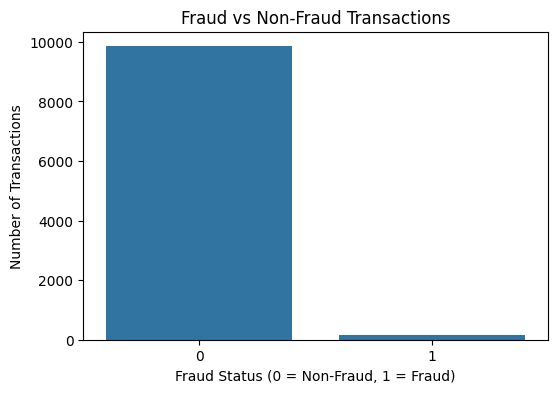

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_fraud')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

Distribution of transaction amounts for fraud vs. non-fraud; time-of-day analysis

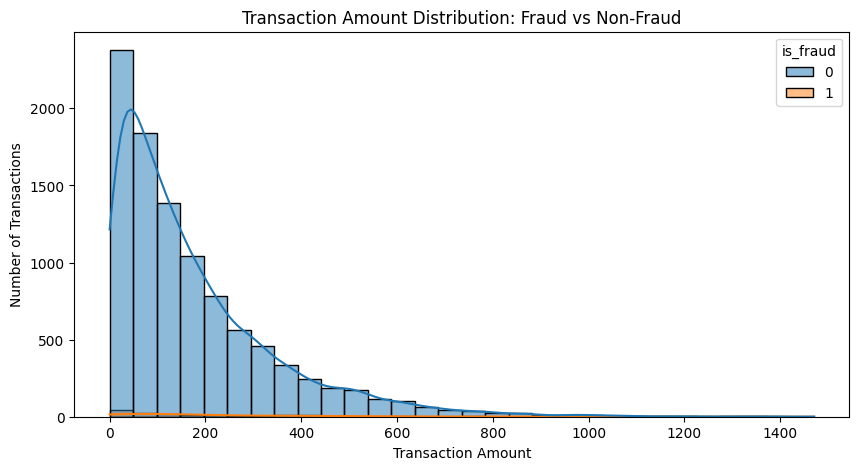

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x='amount',
    hue='is_fraud',
    bins=30,
    kde=True
)
plt.title('Transaction Amount Distribution: Fraud vs Non-Fraud')
plt.xlabel('Transaction Amount')
plt.ylabel('Number of Transactions')
plt.show()

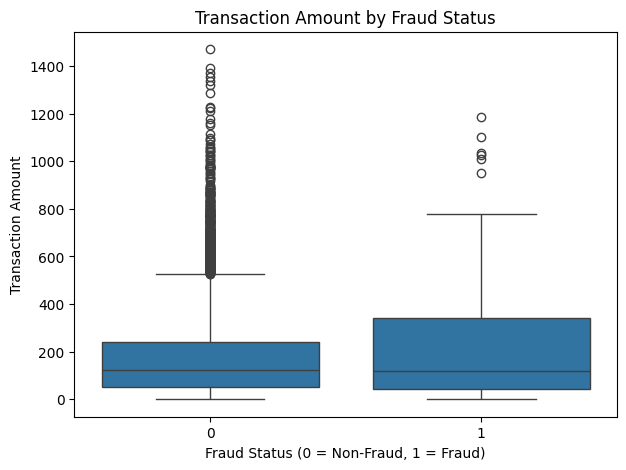

In [13]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x='is_fraud',
    y='amount'
)
plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Status (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Transaction Amount')
plt.show()

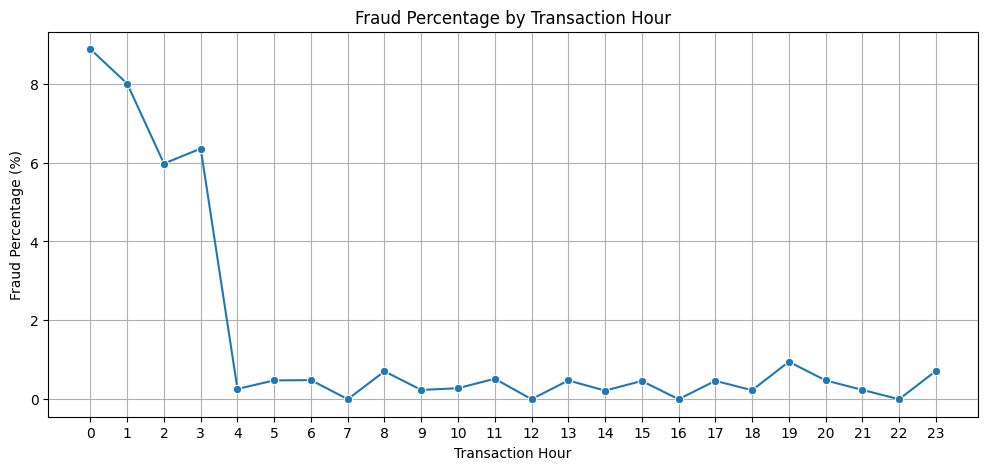

In [16]:
hourly_fraud = df.groupby('transaction_hour')['is_fraud'].mean() * 100

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_fraud.index,
    y=hourly_fraud.values,
    marker='o'
)

plt.title('Fraud Percentage by Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Fraud Percentage (%)')
plt.xticks(range(24))
plt.grid()
plt.show()

standard accuracy is a misleading metric for imbalanced fraud datasets because fraud detection datasets are imbalanced where the number of fraud transactions are less 
For example, Suppose there are 10,000 transactions, of which only 100 are fraudulent. If the model predicts all 10,000 transactions as legitimate, it achieves 99% accuracy, but detects 0% of the fraud.so it fails tu detect the fraud transactions 
Therefore, standard accuracy is not a relaible metric for evaluating fraud detection 

SMOTE oversampling , undersampling or class_weight='balanced' and train test split 

In [18]:
pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   -------------------------- ------------- 2/3 [imblearn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from imblearn.over_sampling import SMOTE

In [20]:
X = df.drop(columns=['is_fraud', 'transaction_id'])

In [21]:
y = df['is_fraud']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical_features = ['merchant_category']

numerical_features = [
    'amount',
    'transaction_hour',
    'foreign_transaction',
    'location_mismatch',
    'device_trust_score',
    'velocity_last_24h',
    'cardholder_age'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [24]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [25]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [26]:
print("Class distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

Class distribution before SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Class distribution after SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


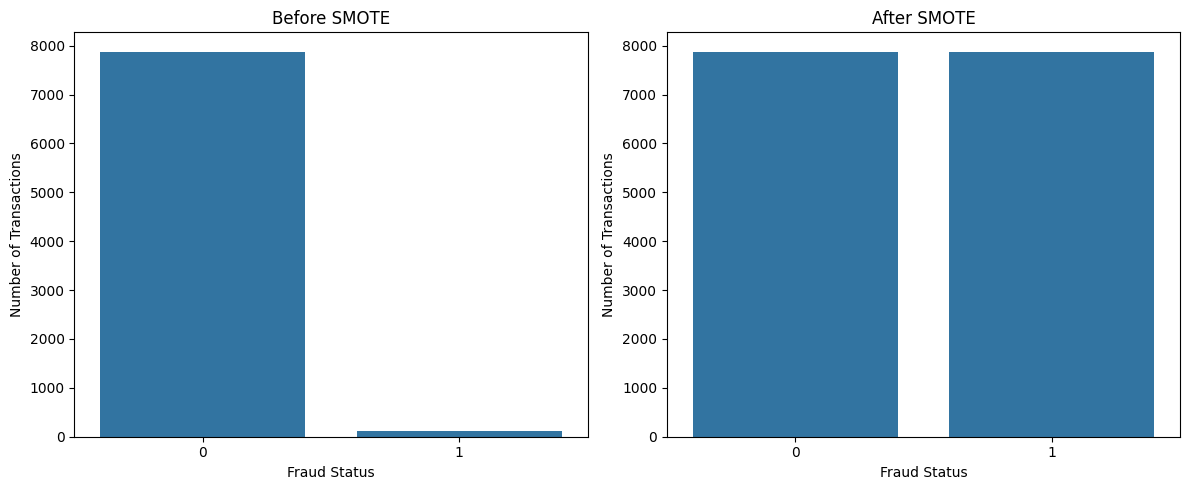

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Fraud Status")
axes[0].set_ylabel("Number of Transactions")

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Fraud Status")
axes[1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

logistic regression model and random forest model 

In [28]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_smote, y_train_smote)
y_pred_lr = logistic_model.predict(X_test_processed)
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

In [30]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test_processed)

y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

In [31]:
print("Logistic Regression predictions:")
print(y_pred_lr[:10])

print("\nRandom Forest predictions:")
print(y_pred_rf[:10])

Logistic Regression predictions:
[0 0 0 0 0 0 0 0 0 0]

Random Forest predictions:
[0 0 0 0 0 0 0 0 0 0]


Precision, Recall, F1-score and AUC-ROC

In [32]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [34]:
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")
print(f"AUC-ROC   : {auc_lr:.4f}")

Logistic Regression
Precision : 0.2871
Recall    : 0.9667
F1-Score  : 0.4427
AUC-ROC   : 0.9933


In [35]:
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"AUC-ROC   : {auc_rf:.4f}")

Random Forest
Precision : 1.0000
Recall    : 0.6667
F1-Score  : 0.8000
AUC-ROC   : 0.9988


In [36]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Precision': [
        precision_lr,
        precision_rf
    ],
    'Recall': [
        recall_lr,
        recall_rf
    ],
    'F1-Score': [
        f1_lr,
        f1_rf
    ],
    'AUC-ROC': [
        auc_lr,
        auc_rf
    ]
})

display(results)

,Model,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.287129,0.966667,0.442748,0.993299
1,Random Forest,1.000000,0.666667,0.800000,0.998799


In [37]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.29      0.97      0.44        30

    accuracy                           0.96      2000
   macro avg       0.64      0.97      0.71      2000
weighted avg       0.99      0.96      0.97      2000


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.67      0.80        30

    accuracy                           0.99      2000
   macro avg       1.00      0.83      0.90      2000
weighted avg       1.00      0.99      0.99      2000



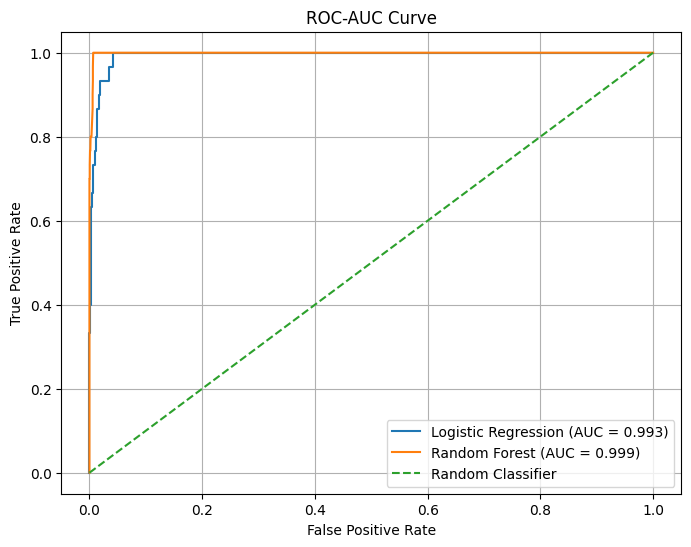

In [38]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {auc_lr:.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.3f})'
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.grid()
plt.show()

Which Metric Matters Most for Fraud Detection?

For fraud detection, Recall is generally more important than Precision because Recall measures the percentage of actual fraudulent transactions that are correctly detected by the model.

A low Recall means that the model is missing many fraudulent transactions, which can result in financial losses. Therefore, a fraud detection system should aim for high Recall so that as many fraudulent transactions as possible are identified.

However, Precision is also important. Precision measures how many transactions predicted as fraudulent are actually fraudulent. If Precision is too low, many legitimate customers may be incorrectly flagged as fraud, causing unnecessary transaction declines or customer inconvenience.

There is therefore a trade-off between Recall and Precision. Increasing Recall may result in more false positives and lower Precision, while increasing Precision may cause some fraudulent transactions to be missed.

For this project, Recall should be given slightly higher importance, because detecting fraudulent transactions is the primary objective. However, the final model should maintain a reasonable Precision to avoid unnecessarily flagging legitimate transactions.

In [40]:
feature_names = preprocessor.get_feature_names_out()
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
)
feature_importance = feature_importance.sort_values(ascending=False)
print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
num__transaction_hour                 0.281689
num__device_trust_score               0.214834
num__foreign_transaction              0.136550
num__velocity_last_24h                0.130033
num__location_mismatch                0.114833
num__amount                           0.024208
cat__merchant_category_Electronics    0.023391
cat__merchant_category_Travel         0.017575
num__cardholder_age                   0.017542
cat__merchant_category_Grocery        0.015614
dtype: float64


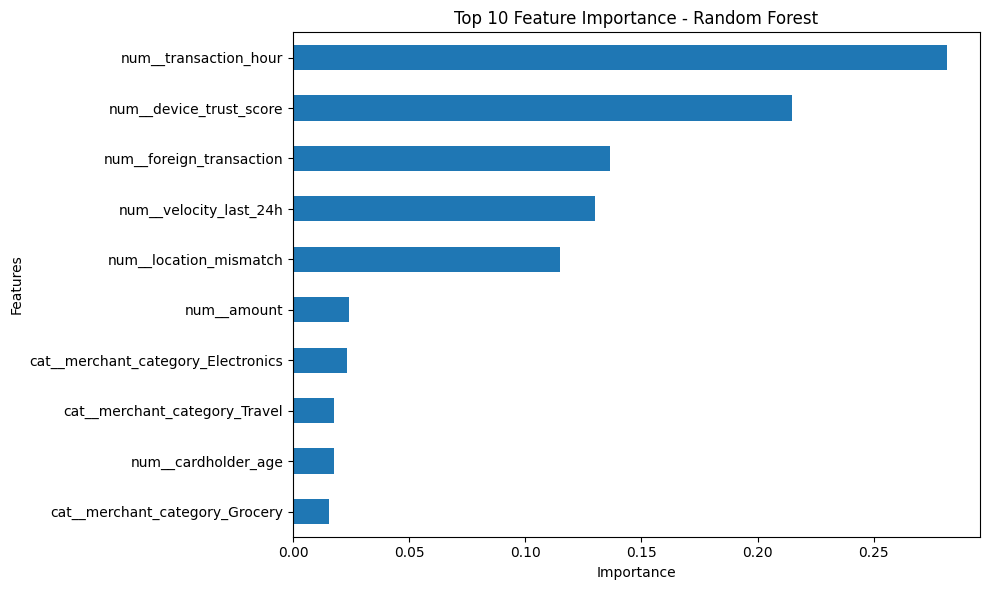

In [41]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

In [42]:
coefficients = pd.Series(
    logistic_model.coef_[0],
    index=feature_names
)

coefficients = coefficients.sort_values(
    key=abs,
    ascending=False
)

print("Top 10 Features by Logistic Regression Coefficient:")
print(coefficients.head(10))

Top 10 Features by Logistic Regression Coefficient:
num__device_trust_score           -4.101777
num__transaction_hour             -3.431620
num__velocity_last_24h             2.616352
num__location_mismatch             2.238664
num__foreign_transaction           2.206095
num__amount                        1.194318
num__cardholder_age               -0.908595
cat__merchant_category_Clothing   -0.766080
cat__merchant_category_Food        0.332362
cat__merchant_category_Grocery     0.308039
dtype: float64


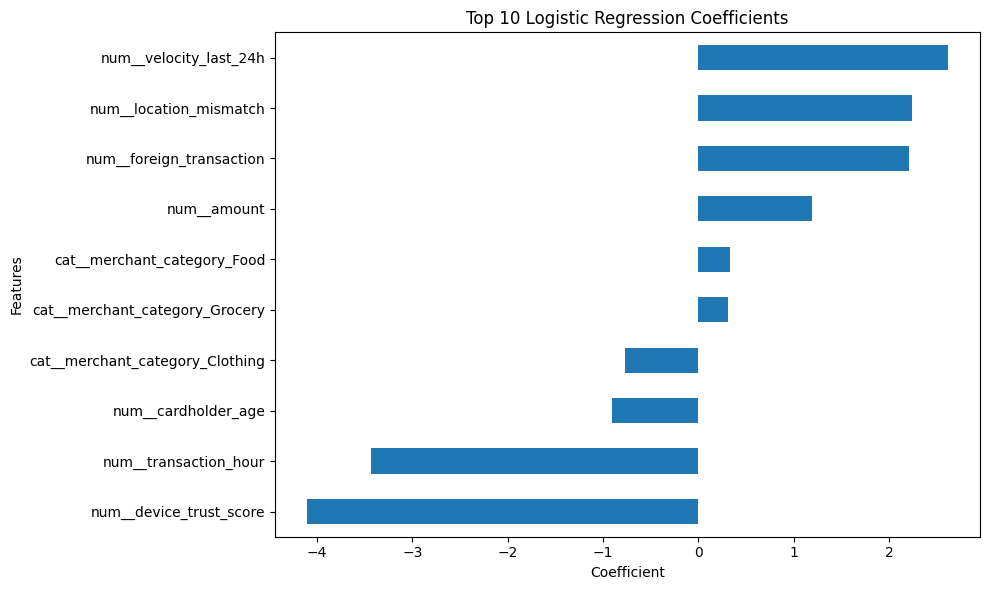

In [43]:
plt.figure(figsize=(10, 6))

coefficients.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

Scalability: Handling 1 Million Transactions per Hour

A fraud detection system handling 1 million transactions per hour would need to process approximately 278 transactions per second. The trained machine learning model can be deployed as a real-time prediction service to classify incoming transactions as fraudulent or non-fraudulent.

For large-scale processing, the system can use a streaming platform such as Apache Kafka to receive transactions continuously. Multiple model-serving instances can process transactions in parallel, allowing the system to handle high traffic.

The preprocessing steps, such as scaling numerical features and encoding categorical variables, should be saved along with the trained model so that every new transaction is processed consistently. The Random Forest model can be optimized by controlling the number of trees and model complexity to achieve a balance between prediction accuracy and response time.

For very high transaction volumes, distributed processing tools such as Apache Spark can be used for batch processing and large-scale feature engineering. The system should also include monitoring for model performance, data drift, and changes in fraud patterns. The model can be retrained periodically using newly collected transaction data.

Therefore, the model can be scaled to handle 1 million transactions per hour by combining efficient preprocessing, parallel model serving, streaming infrastructure, distributed processing, and continuous monitoring.

In [44]:
transactions_per_hour = 1_000_000
transactions_per_second = transactions_per_hour / 3600

print(f"Transactions per hour: {transactions_per_hour:,}")
print(f"Transactions per second: {transactions_per_second:.2f}")

Transactions per hour: 1,000,000
Transactions per second: 277.78
